# Influential Outlier Metric for PISA data

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = (
    SparkSession.builder
    .appName("LocalSpark")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)

print("Spark version:", spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/08/10 15:36:04 WARN Utils: Your hostname, Colins-Mac-mini.local, resolves to a loopback address: 127.0.0.1; using 192.168.0.12 instead (on interface en1)
26/08/10 15:36:04 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/Users/colinjones/Desktop/PhD_PISA/.venv/lib/python3.12/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/08/10 15:36:05 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.2.0


In [2]:
import numpy as np
import pandas as pd
import pyreadstat
import seaborn as sns
import matplotlib.pyplot as plt
import warnings


from joblib import Parallel, delayed
from tqdm import tqdm, trange

from scipy import stats

import optuna
from optuna.integration import XGBoostPruningCallback
from optuna.visualization import plot_optimization_history

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler

from xgboost import XGBRegressor
import xgboost as xgb
from xgboost.callback import EarlyStopping

from statsmodels.regression.linear_model import OLS
from statsmodels.regression.mixed_linear_model import MixedLM


from iom import InfluentialOutlierMetric

/Users/colinjones/Desktop/PhD_PISA/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/homebrew/Cellar/python@3.12/3.12.13_4/Frameworks/Python.framework/Versions/3.12/lib/python3.12/importlib/__init__.py:90: FutureWarning: `optuna.integration.xgboost` has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0. Use `optuna_integration.xgboost` instead.
  return _bootstrap._gcd_import(name[level:], package, level)


## MEGB

In [3]:
class MEGB_CPU:
    def __init__(
        self,
        xgb_params=None,
        max_iter=6,
        tol=1e-4,
        random_state=42,
    ):
        xgb_params = dict(xgb_params or {})

        xgb_params.setdefault("learning_rate", 0.05)
        xgb_params.setdefault("max_depth", 6)
        xgb_params.setdefault("subsample", 0.9)
        xgb_params.setdefault("colsample_bytree", 0.9)
        xgb_params.setdefault("objective", "reg:squarederror")

        # CPU settings
        xgb_params.setdefault("tree_method", "hist")
        xgb_params.setdefault("device", "cpu")

        xgb_params.setdefault("nthread", -1)
        xgb_params.setdefault("verbosity", 0)
        xgb_params.setdefault("seed", random_state)

        self.xgb_params = xgb_params
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

        self.booster = None
        self.bhat = None
        self.group_map = None
        self.sigma2_hat = None

    def fit(self, X, y, groups):
        X = np.asarray(X, dtype=np.float32)
        y = np.asarray(y, dtype=np.float32)
        groups = np.asarray(groups)

        unique_groups, group_idx = np.unique(
            groups,
            return_inverse=True,
        )
        counts = np.bincount(group_idx).astype(np.float32)

        tr_idx, val_idx = train_test_split(
            np.arange(len(y)),
            test_size=0.2,
            random_state=self.random_state,
        )

        dtrain = xgb.DMatrix(X[tr_idx], label=y[tr_idx])
        dvalid = xgb.DMatrix(X[val_idx], label=y[val_idx])
        dfull = xgb.DMatrix(X)

        bhat = np.zeros(len(unique_groups), dtype=np.float32)
        mu_hat = np.zeros_like(y)
        sigma2 = np.var(y)

        booster = None

        for _ in range(self.max_iter):
            # Fixed-effects update
            dtrain.set_label(
                y[tr_idx] - bhat[group_idx[tr_idx]]
            )
            dvalid.set_label(
                y[val_idx] - bhat[group_idx[val_idx]]
            )

            booster = xgb.train(
                params=self.xgb_params,
                dtrain=dtrain,
                num_boost_round=500,
                evals=[(dvalid, "val")],
                early_stopping_rounds=20,
                xgb_model=booster,
                verbose_eval=False,
            )

            mu_hat[:] = booster.predict(dfull)

            # Random-intercept update
            residuals = y - mu_hat
            bhat_new = (
                np.bincount(group_idx, weights=residuals)
                / counts
            ).astype(np.float32)

            # Residual-variance update
            full_residuals = (
                y - mu_hat - bhat_new[group_idx]
            )
            sigma2_new = np.mean(full_residuals**2)

            converged = (
                abs(sigma2_new - sigma2)
                < self.tol * (sigma2 + 1e-12)
            )

            bhat = bhat_new
            sigma2 = sigma2_new

            if converged:
                break

        self.booster = booster
        self.bhat = bhat
        self.group_map = {
            group: index
            for index, group in enumerate(unique_groups)
        }
        self.sigma2_hat = sigma2

        return self

    def predict(self, X, groups):
        if self.booster is None:
            raise RuntimeError(
                "The model must be fitted before calling predict()."
            )

        X = np.asarray(X, dtype=np.float32)
        groups = np.asarray(groups)

        dmat = xgb.DMatrix(X)
        y_fixed = self.booster.predict(dmat)

        group_idx = np.array(
            [self.group_map.get(group, -1) for group in groups],
            dtype=int,
        )

        random_effects = np.zeros(
            len(groups),
            dtype=np.float32,
        )
        known_groups = group_idx >= 0
        random_effects[known_groups] = self.bhat[
            group_idx[known_groups]
        ]

        return y_fixed + random_effects

In [4]:
def stratified_by_group_kfold_megb_loss_cpu(
    trial,
    MEGBClass,
    xgb_params,
    max_iter,
    tol,
    X,
    y,
    groups,
    splits,
):
    rmse_list = []

    for fold_id, (train_idx, test_idx) in enumerate(splits):
        X_tr, y_tr = X[train_idx], y[train_idx]
        X_te, y_te = X[test_idx], y[test_idx]
        groups_tr = groups[train_idx]
        groups_te = groups[test_idx]

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            model = MEGBClass(
                xgb_params=xgb_params,
                max_iter=max_iter,
                tol=tol,
                random_state=42 + fold_id,
            )

            model.fit(X_tr, y_tr, groups_tr)
            preds = model.predict(X_te, groups_te)

        rmse = np.sqrt(mean_squared_error(y_te, preds))
        rmse_list.append(rmse)

        # Optuna pruning
        trial.report(rmse, step=fold_id)

        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(rmse_list))


def objective_megb_cpu(trial, X, y, groups, splits):
    xgb_params = {
        # CPU settings
        "device": "cpu",
        "tree_method": "hist",
        "nthread": -1,

        # Tuned parameters
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.02, 0.2
        ),
        "max_depth": trial.suggest_int(
            "max_depth", 3, 8
        ),
        "subsample": trial.suggest_float(
            "subsample", 0.6, 1.0
        ),
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.6, 1.0
        ),
        "min_child_weight": trial.suggest_int(
            "min_child_weight", 1, 10
        ),
        "gamma": trial.suggest_float(
            "gamma", 0.0, 2.0
        ),
    }

    # Keep the EM search relatively narrow
    max_iter = trial.suggest_int("max_iter", 3, 8)
    tol = trial.suggest_float(
        "tol",
        1e-5,
        1e-3,
        log=True,
    )

    return stratified_by_group_kfold_megb_loss_cpu(
        trial=trial,
        MEGBClass=MEGB_CPU,
        xgb_params=xgb_params,
        max_iter=max_iter,
        tol=tol,
        X=X,
        y=y,
        groups=groups,
        splits=splits,
    )


def tune_megb_cpu(
    X,
    y,
    groups,
    n_trials=50,
    n_jobs=8,
):
    X_np = np.asarray(X)
    y_np = np.asarray(y)
    groups_np = np.asarray(groups)

    # Precompute CV splits once
    skf = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=42,
    )

    splits = list(
        skf.split(X_np, groups_np)
    )

    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(
            n_startup_trials=10,
            n_warmup_steps=2,
        ),
    )

    study.optimize(
        lambda trial: objective_megb_cpu(
            trial,
            X_np,
            y_np,
            groups_np,
            splits,
        ),
        n_trials=n_trials,
        n_jobs=n_jobs,
        show_progress_bar=True,
    )

    # fig = plot_optimization_history(study)
    # fig.write_html("megb_cpu_history.html")

    return study.best_params

## Small model

In [5]:
Data = spark.read.parquet("./pisa_spark_stu/").select("CNT", 'CNTSCHID', 'CNTSTUID', "PV1MATH", "ESCS").filter(F.col("CNT").isin("SGP", "PHL")).toPandas().dropna()
Data = Data.set_index('CNTSTUID')

/Users/colinjones/Desktop/PhD_PISA/.venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/Users/colinjones/Desktop/PhD_PISA/.venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


In [6]:
X = Data.drop(columns=['CNTSCHID', "CNT", 'PV1MATH'])
y = Data['PV1MATH']
groups = Data['CNTSCHID']

X_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(X, y, groups, test_size=0.2, random_state=42)

In [7]:
best_megb = tune_megb_cpu(X_train, y_train, groups_train, n_trials=16)

[I 2026-08-10 15:36:17,551] A new study created in memory with name: no-name-db61dd12-be8c-451f-b35d-c5d9a156cd34
Best trial: 3. Best value: 74.639:   6%|▋         | 1/16 [00:03<00:58,  3.88s/it]

[I 2026-08-10 15:36:21,444] Trial 3 finished with value: 74.63901013415743 and parameters: {'learning_rate': 0.15828437626264938, 'max_depth': 6, 'subsample': 0.6216024504264577, 'colsample_bytree': 0.6221697832725946, 'min_child_weight': 1, 'gamma': 1.7568290350247833, 'max_iter': 3, 'tol': 1.2643955533942187e-05}. Best is trial 3 with value: 74.63901013415743.


Best trial: 5. Best value: 71.5799:  12%|█▎        | 2/16 [00:05<00:38,  2.77s/it]

[I 2026-08-10 15:36:23,442] Trial 5 finished with value: 71.57990147121905 and parameters: {'learning_rate': 0.09015962953767367, 'max_depth': 3, 'subsample': 0.9680791302182772, 'colsample_bytree': 0.6290746668434476, 'min_child_weight': 6, 'gamma': 0.17652257890286882, 'max_iter': 7, 'tol': 8.258419786367754e-05}. Best is trial 5 with value: 71.57990147121905.


Best trial: 5. Best value: 71.5799:  19%|█▉        | 3/16 [00:06<00:22,  1.73s/it]

...

[I 2026-08-10 15:36:36,779] Trial 15 pruned. 
[I 2026-08-10 15:36:36,955] Trial 14 pruned. 


Best trial: 5. Best value: 71.5799:  88%|████████▊ | 14/16 [00:19<00:01,  1.28it/s]

[I 2026-08-10 15:36:37,326] Trial 6 pruned. 


Best trial: 5. Best value: 71.5799: 100%|██████████| 16/16 [00:20<00:00,  1.29s/it]

[I 2026-08-10 15:36:38,051] Trial 13 pruned. 
[I 2026-08-10 15:36:38,246] Trial 9 finished with value: 71.86949338170136 and parameters: {'learning_rate': 0.022682518805861977, 'max_depth': 4, 'subsample': 0.9236063894379463, 'colsample_bytree': 0.746293932662211, 'min_child_weight': 1, 'gamma': 0.33727904429006483, 'max_iter': 8, 'tol': 1.3569670709845348e-05}. Best is trial 5 with value: 71.57990147121905.


In [8]:
megb_params = ['max_iter', 'tol']
xgb_params = {k: v for k, v in best_megb.items() if k not in megb_params}

# Initialize MEGB with unpacked parameters
best_model = MEGB_CPU(
    xgb_params=xgb_params,
    max_iter=best_megb.get('max_iter', 10),
    tol=best_megb.get('tol', 1e-4)
)

best_model.fit(X_train, y_train, groups_train)

In [9]:
print("Test RMSE:", np.sqrt(mean_squared_error(best_model.predict(X_test, groups_test), y_test)))

Test RMSE: 71.38869525179888


### Student level

In [10]:
shap_values = best_model.booster.predict(
    xgb.DMatrix(np.asarray(X, dtype=np.float32)),
    pred_contribs=True
)

In [11]:
resid = Data['PV1MATH'] - best_model.predict(Data.drop(columns=['CNTSCHID', "CNT", 'PV1MATH']), Data['CNTSCHID'])

<Axes: ylabel='Count'>

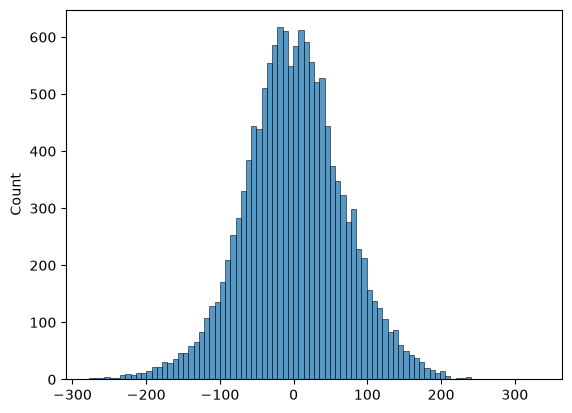

In [12]:
sns.histplot(resid.values)

<Axes: ylabel='Count'>

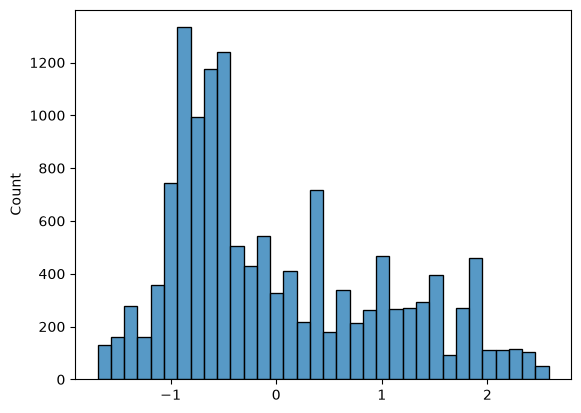

In [13]:
sns.histplot(StandardScaler().fit_transform(shap_values[:,0].reshape(-1,1)).ravel())

In [14]:
iom = InfluentialOutlierMetric()

In [3]:
device = torch.device("mps" if torch.backends.mps.is_available() else 'cpu')
torch.use_deterministic_algorithms(True, warn_only=True)

In [ ]:
results_iom = iom.find_best_lambda(
    StandardScaler().fit_transform(shap_values[:,0].reshape(-1,1)),
    K=4,
    hidden=4,
    layers=2,
    epoch=1000,
    loc=[0],
    scale=[1],
    tail_bound=2.5,
    num_bins=10,
    torch_seed=42
)

lambda: 0.0
mps


Normalizing flow:  20%|█▉        | 195/1000 [01:03<03:49,  3.51it/s]

In [ ]:
results_iom_resid = iom.find_best_lambda(
    StandardScaler().fit_transform(resid.values.reshape(-1,1)),
    K=2,
    hidden=2,
    layers=2,
    epoch=500,
    loc=[0],
    scale=[1],
    tail_bound=3,
    num_bins=8,
    torch_seed=42
)

In [ ]:
iom.IOM(results_iom, results_iom_resid)

In [ ]:
Data['IOM_i'] = iom.IOM_.values
Data['SHAP_z'] = results_iom['chi_z']
Data['resid_z'] = results_iom_resid['chi_z']

In [ ]:
Data[Data['IOM_i'] > 12.9904].sort_values(by='IOM_i', ascending=False).shape

In [ ]:
Data[Data['IOM_i'] > 12.9904].sort_values(by='IOM_i', ascending=False).head()

### School level

In [ ]:
Data_group = pd.concat([pd.Series(best_model.group_map.keys()), pd.Series(best_model.bhat)], axis=1)
Data_group.columns = ['CNTSCHID', 'bhat']

In [ ]:
Data_group_final = Data_group.merge(Data[['CNTSCHID', 'CNT']], on='CNTSCHID', how='left').drop_duplicates()
Data_group_final = Data_group_final.rename(columns={'CNT': 'Country'})

In [ ]:
sns.histplot(Data_group_final, x='bhat', hue='Country')
plt.xlabel("Random intercept")

In [ ]:
iom_sch = InfluentialOutlierMetric()

In [ ]:
results_iom_sch_bm = iom_sch.find_best_lambda(
    best_model.bhat.reshape(-1,1),
    K=2,
    hidden=2,
    layers=2,
    epoch=500,
    loc=[-100, 100],
    scale=[50, 50],
    tail_bound=250,
    num_bins=16,
    torch_seed=42
)

In [ ]:
results_iom_sch_um = iom_sch.find_best_lambda(
    best_model.bhat.reshape(-1,1),
    K=2,
    hidden=2,
    layers=2,
    epoch=500,
    loc=[0],
    scale=[100],
    tail_bound=250,
    num_bins=16,
    torch_seed=42
)

In [ ]:
iom_sch.select_flow_by_transport_modes([results_iom_sch_um, results_iom_sch_bm])

In [ ]:
Data_group_final['bhat_z'] = results_iom_sch_bm['chi_z']

In [ ]:
stats.chi2.ppf(0.95, df=1)

In [ ]:
Data_group_final[Data_group_final['bhat_z'] > stats.chi2.ppf(0.95, df=1)].sort_values(by='bhat_z', ascending=False)

## Full model

Variables
* MATHPERS: Persistence in mathematics
* ANXMAT: Anxiety in math
* TOTMATH: Number of mathematics teachers
* SCHSIZE: School size




In [81]:
Data = spark.read.parquet("/content/drive/MyDrive/pisa_spark_stu/").select("CNT", 'CNTSCHID', 'CNTSTUID', "PV1MATH", "ESCS", "MATHPERS", "ANXMAT").filter(F.col("CNT").isin("SGP", "PHL")).toPandas().dropna()
Data['CNTSCHID'] = Data['CNTSCHID'].astype(str)

In [82]:
Data_sch = pd.read_spss("/content/drive/MyDrive/PISA/CY08MSP_SCH_QQQ.SAV")[["CNTSCHID", "TOTMATH", "SCHSIZE"]].dropna()
Data_sch['CNTSCHID'] = Data_sch['CNTSCHID'].astype(str)

In [83]:
Data_final = Data.merge(Data_sch, on="CNTSCHID", how="left").dropna()
Data_final = Data_final.set_index('CNTSTUID')

In [84]:
Data_final

,CNT,CNTSCHID,PV1MATH,ESCS,MATHPERS,ANXMAT,TOTMATH,SCHSIZE
CNTSTUID,,,,,,,,
70200001.0,SGP,70200052.0,639.004,0.1836,-0.1305,0.3729,14.5,1224.0
70200002.0,SGP,70200134.0,697.191,0.8261,0.6178,0.6647,13.5,1069.0
70200003.0,SGP,70200112.0,693.710,-1.0357,-0.3993,0.0510,13.0,1165.0
70200004.0,SGP,70200004.0,427.317,-0.9606,1.8158,0.6387,16.0,1112.0
70200005.0,SGP,70200152.0,436.462,0.0856,1.1353,2.5026,15.5,899.0
...,...,...,...,...,...,...,...,...
70207341.0,SGP,70200110.0,704.039,0.9349,0.0635,0.1932,45.0,3675.0
70207342.0,SGP,70200045.0,521.291,0.4124,2.0614,0.4290,12.0,1159.0
70207343.0,SGP,70200014.0,532.107,0.2619,0.0950,0.1932,12.0,382.0


In [85]:
X = Data_final.drop(columns=['CNTSCHID', "CNT", 'PV1MATH'])
y = Data_final['PV1MATH']
groups = Data_final['CNTSCHID']

X_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(X, y, groups, test_size=0.2, random_state=42)

In [86]:
best_megb = tune_megb_gpu(X_train, y_train, groups_train, n_trials=64)

[I 2026-08-10 15:44:27,619] A new study created in memory with name: no-name-5fdbf94a-9646-475b-8570-1ad8a258729f


  0%|          | 0/64 [00:00<?, ?it/s]

[I 2026-08-10 15:44:32,784] Trial 0 finished with value: 92.20580112117888 and parameters: {'learning_rate': 0.19135317742696908, 'max_depth': 7, 'subsample': 0.6302903277665751, 'colsample_bytree': 0.8971954820980865, 'min_child_weight': 5, 'gamma': 0.9490097746795636, 'max_iter': 8, 'tol': 8.8905085859175e-05}. Best is trial 0 with value: 92.20580112117888.
[I 2026-08-10 15:44:33,105] Trial 1 finished with value: 82.15570986005326 and parameters: {'learning_rate': 0.040474618480319136, 'max_depth': 5, 'subsample': 0.8284104708018306, 'colsample_bytree': 0.6782745567267484, 'min_child_weight': 8, 'gamma': 1.8495937881521725, 'max_iter': 6, 'tol': 0.00011988128891146936}. Best is trial 1 with value: 82.15570986005326.
[I 2026-08-10 15:44:34,902] Trial 2 finished with value: 84.75769219470762 and parameters: {'learning_rate': 0.12521409075092715, 'max_depth': 6, 'subsample': 0.9080448809100485, 'colsample_bytree': 0.8682126281231166, 'min_child_weight': 9, 'gamma': 0.05859513287515594, 

In [89]:
megb_params = ['max_iter', 'tol']
xgb_params = {k: v for k, v in best_megb.items() if k not in megb_params}

# Initialize MEGB with unpacked parameters
best_model = MEGB_GPU(
    xgb_params=xgb_params,
    max_iter=best_megb.get('max_iter', 10),
    tol=best_megb.get('tol', 1e-4)
)

best_model.fit(X_train, y_train, groups_train)

In [90]:
print("Test RMSE:", np.sqrt(mean_squared_error(best_model.predict(X_test, groups_test), y_test)))

Test RMSE: 78.73459477170108


### Student level

In [91]:
shap_values = best_model.booster.predict(
    xgb.DMatrix(np.asarray(X, dtype=np.float32)),
    pred_contribs=True
)

In [98]:
shap_values = pd.DataFrame(shap_values)
shap_values.columns = ['ESCS', 'MATHPERS', 'ANXMAT', 'TOTMATH', 'SCHSIZE', 'Intercept']

In [92]:
resid = Data_final['PV1MATH'] - best_model.predict(X, Data_final['CNTSCHID'])

<Axes: ylabel='Count'>

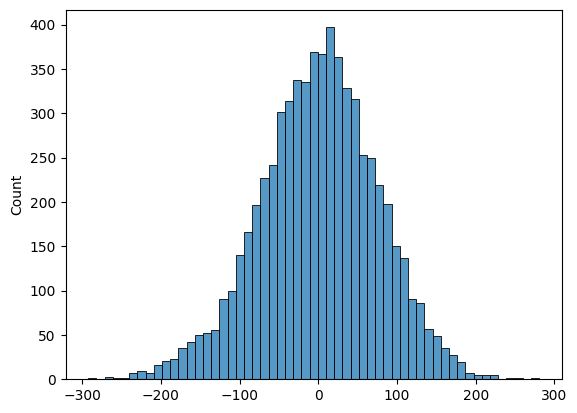

In [95]:
sns.histplot(resid.values)

<Axes: ylabel='Count'>

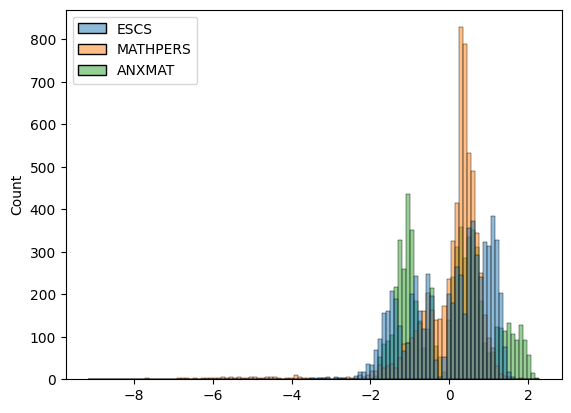

In [101]:
shap_values_stu_s = pd.DataFrame(StandardScaler().fit_transform(shap_values[['ESCS', 'MATHPERS', 'ANXMAT']]), columns= ['ESCS', 'MATHPERS', 'ANXMAT'])
sns.histplot(shap_values_stu_s)

In [ ]:
from sklearn.mixture import GaussianMixture

def best_gmm(X, max_components=15):
    models = [
        GaussianMixture(k, n_init=10, random_state=42).fit(X)
        for k in range(1, max_components + 1)
    ]
    return models[np.argmin([m.bic(X) for m in models])]

In [ ]:
gmm = best_gmm(shap_values[:,:3])
print(gmm.n_components)

In [102]:
iom = InfluentialOutlierMetric()

In [105]:
results_iom = iom.find_best_lambda(
    shap_values_stu_s.values,
    K=10,
    hidden=10,
    layers=4,
    epoch=1000,
    loc=[0],
    scale=[1],
    tail_bound=9,
    num_bins=16,
    torch_seed=42
)

lambda: 0.0
cuda


Normalizing flow: 100%|██████████| 1000/1000 [04:46<00:00,  3.49it/s]


--- Whitened mode-normality diagnostics (n=6513, d=3, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 6513  test: Henze-Zirkler  pvalue: 0.0703

[1b] Stouffer combined normality p-value
     z = 1.4734
     p = 0.07032
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.2809
    CvM p-value: 0.5683
    Q mean:      3.0109  expected approx d=3
    Q max:       63.9484
    min tail p:  8.419e-14
lambda: 0.006737946999085467
cuda


Normalizing flow: 100%|██████████| 1000/1000 [04:54<00:00,  3.39it/s]


--- Whitened mode-normality diagnostics (n=6513, d=3, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 6513  test: Henze-Zirkler  pvalue: 0.0048

[1b] Stouffer combined normality p-value
     z = 2.5865
     p = 0.004848
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.1527
    CvM p-value: 0.0396
    Q mean:      2.9542  expected approx d=3
    Q max:       74.8943
    min tail p:  3.817e-16
Final lambda: 0.0000
Mean test distance: 0.6229
Final weights: [np.float32(1.0)]
Final means: [array([-0.0005, -0.0609,  0.006 ], dtype=float32)]
Final scales: [array([1.0382, 1.1512, 0.9576], dtype=float32)]


In [106]:
results_iom_resid = iom.find_best_lambda(
    StandardScaler().fit_transform(resid.values.reshape(-1,1)),
    K=2,
    hidden=2,
    layers=2,
    epoch=500,
    loc=[0],
    scale=[1],
    tail_bound=3,
    num_bins=8,
    torch_seed=42
)

lambda: 0.0
cuda


Normalizing flow: 100%|██████████| 500/500 [00:23<00:00, 20.85it/s]


--- Whitened mode-normality diagnostics (n=6513, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 6513  test: Jarque-Bera  pvalue: 0.4587

[1b] Stouffer combined normality p-value
     z = 0.1037
     p = 0.4587
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.5498
    CvM p-value: 0.2823
    Q mean:      1.0244  expected approx d=1
    Q max:       14.1856
    min tail p:  0.0001656
lambda: 0.006737946999085467
cuda


Normalizing flow: 100%|██████████| 500/500 [00:23<00:00, 21.36it/s]


--- Whitened mode-normality diagnostics (n=6513, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 6513  test: Jarque-Bera  pvalue: 0.4464

[1b] Stouffer combined normality p-value
     z = 0.1348
     p = 0.4464
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.5666
    CvM p-value: 0.2985
    Q mean:      1.0244  expected approx d=1
    Q max:       14.2225
    min tail p:  0.0001624
lambda: 0.013123728736940968
cuda


...

--- Whitened mode-normality diagnostics (n=6513, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 6513  test: Jarque-Bera  pvalue: 0.2613

[1b] Stouffer combined normality p-value
     z = 0.6393
     p = 0.2613
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.8439
    CvM p-value: 0.5475
    Q mean:      1.0244  expected approx d=1
    Q max:       14.5297
    min tail p:  0.000138
lambda: 0.18887560283756177
cuda


Normalizing flow: 100%|██████████| 500/500 [00:24<00:00, 20.50it/s]


--- Whitened mode-normality diagnostics (n=6513, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 6513  test: Jarque-Bera  pvalue: 0.1227

[1b] Stouffer combined normality p-value
     z = 1.1617
     p = 0.1227
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.9530
    CvM p-value: 0.7376
    Q mean:      1.0245  expected approx d=1
    Q max:       14.7112
    min tail p:  0.0001253
lambda: 0.36787944117144233
cuda


Normalizing flow: 100%|██████████| 500/500 [00:24<00:00, 20.72it/s]


--- Whitened mode-normality diagnostics (n=6513, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 6513  test: Jarque-Bera  pvalue: 0.0278

[1b] Stouffer combined normality p-value
     z = 1.9137
     p = 0.02783
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.9484
    CvM p-value: 0.9094
    Q mean:      1.0251  expected approx d=1
    Q max:       14.8959
    min tail p:  0.0001136
Final lambda: 0.1889
Mean test distance: 0.0125
Final weights: [np.float32(1.0)]
Final means: [array([-0.1049], dtype=float32)]
Final scales: [array([1.0007], dtype=float32)]


In [107]:
iom.IOM(results_iom, results_iom_resid)

,IOM
0,0.968481
1,36.173967
2,4.737675
3,0.749064
4,0.926928
...,...
6508,0.021487
6509,0.087833
6510,0.011848
6511,0.162872


In [108]:
Data_final['IOM_i'] = iom.IOM_.values
Data_final['SHAP_z'] = results_iom['chi_z']
Data_final['resid_z'] = results_iom_resid['chi_z']

In [113]:
365/6513

0.056041762628588974

In [111]:
Data_final.shape

(6513, 11)

In [112]:
Data_final[Data_final['IOM_i'] > 12.9904].sort_values(by='IOM_i', ascending=False)

,CNT,CNTSCHID,PV1MATH,ESCS,MATHPERS,ANXMAT,TOTMATH,SCHSIZE,IOM_i,SHAP_z,resid_z
CNTSTUID,,,,,,,,,,,
70201945.0,SGP,70200130.0,326.435,0.8142,-2.2572,1.5706,35.0,1275.0,233.003397,63.948400,3.643616
70206015.0,SGP,70200002.0,602.746,-1.7252,-2.9712,2.5026,20.0,918.0,120.307299,17.681155,6.804267
70203381.0,SGP,70200076.0,943.041,1.1072,0.9681,-2.3820,13.5,1091.0,94.310950,6.410822,14.711210
70206650.0,SGP,70200118.0,827.772,-0.6465,-0.2687,-1.6297,18.0,1286.0,91.479450,7.440898,12.294140
70205121.0,SGP,70200088.0,811.206,-1.2908,-1.1241,-1.6297,14.0,1095.0,89.283199,13.809780,6.465215
...,...,...,...,...,...,...,...,...,...,...,...
70202362.0,SGP,70200004.0,661.251,-1.0528,-0.1647,-0.9158,16.0,1112.0,13.120302,6.188812,2.120003
70205026.0,SGP,70200086.0,361.847,-0.5095,0.3039,2.6109,13.0,1136.0,13.117406,4.927826,2.661905
70203998.0,SGP,70200130.0,774.955,0.2192,-0.5923,-0.3744,35.0,1275.0,13.114761,2.201677,5.956715


In [110]:
Data_final[Data_final['IOM_i'] > 12.9904].sort_values(by='IOM_i', ascending=False).head()

,CNT,CNTSCHID,PV1MATH,ESCS,MATHPERS,ANXMAT,TOTMATH,SCHSIZE,IOM_i,SHAP_z,resid_z
CNTSTUID,,,,,,,,,,,
70201945.0,SGP,70200130.0,326.435,0.8142,-2.2572,1.5706,35.0,1275.0,233.003397,63.948400,3.643616
70206015.0,SGP,70200002.0,602.746,-1.7252,-2.9712,2.5026,20.0,918.0,120.307299,17.681155,6.804267
70203381.0,SGP,70200076.0,943.041,1.1072,0.9681,-2.3820,13.5,1091.0,94.310950,6.410822,14.711210
70206650.0,SGP,70200118.0,827.772,-0.6465,-0.2687,-1.6297,18.0,1286.0,91.479450,7.440898,12.294140
70205121.0,SGP,70200088.0,811.206,-1.2908,-1.1241,-1.6297,14.0,1095.0,89.283199,13.809780,6.465215


### School level

<Axes: ylabel='Count'>

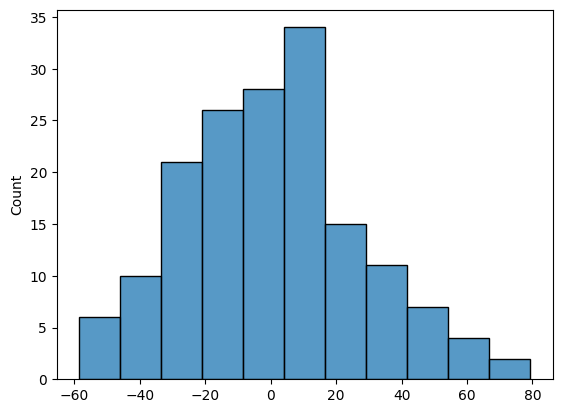

In [140]:
sns.histplot(best_model.bhat)

In [127]:
shap_values

,ESCS,MATHPERS,ANXMAT,TOTMATH,SCHSIZE,Intercept,group
0,-16.583227,3.998832,-0.450265,2.889449,9.550434,572.579407,NaN
1,19.841589,8.082407,-31.604935,-1.355225,-5.751976,572.579407,NaN
2,-39.468624,-4.174438,14.181029,-3.021996,9.330350,572.579407,NaN
3,-40.885689,3.234860,-32.389786,-0.067479,-7.137995,572.579407,NaN
4,-14.977515,7.192338,-26.312773,-1.878110,-35.967953,572.579407,NaN
...,...,...,...,...,...,...,...
6508,20.093111,2.489900,4.435746,35.436485,30.595844,572.579407,NaN
6509,6.309521,-11.206634,-7.326138,-2.493021,-5.556878,572.579407,NaN
6510,1.238422,2.273201,3.571492,-1.144631,-33.790379,572.579407,NaN
6511,6.635558,-1.538908,8.106943,-1.704742,-23.173450,572.579407,NaN


In [128]:
Data_final['CNTSCHID'].shape

(6513,)

In [129]:
shap_values['group'] = Data_final['CNTSCHID'].values
shap_sch = shap_values[['TOTMATH', 'SCHSIZE', 'group']].groupby("group").mean()

<Axes: ylabel='Count'>

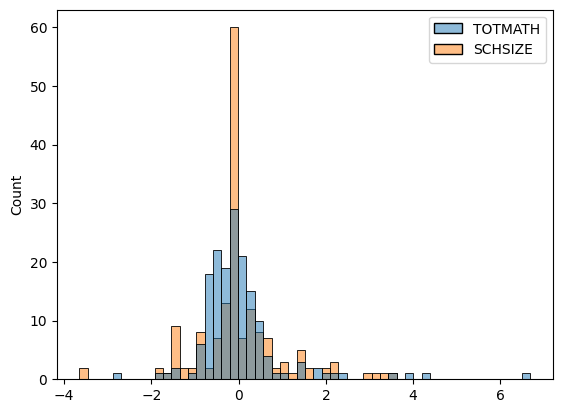

In [131]:
shap_sch_s = pd.DataFrame(StandardScaler().fit_transform(shap_sch), columns = ['TOTMATH', 'SCHSIZE'])
sns.histplot(shap_sch_s)

In [132]:
iom_sch = InfluentialOutlierMetric()

In [139]:
results_iom_sch = iom_sch.find_best_lambda(
    shap_sch_s.values,
    K=4,
    hidden=4,
    layers=4,
    epoch=1000,
    loc=[0],
    scale=[1],
    tail_bound=7,
    num_bins=12,
    torch_seed=42
)

lambda: 0.0
cuda


Normalizing flow: 100%|██████████| 1000/1000 [01:35<00:00, 10.48it/s]


--- Whitened mode-normality diagnostics (n=164, d=2, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 164  test: Henze-Zirkler  pvalue: 0.2845

[1b] Stouffer combined normality p-value
     z = 0.5696
     p = 0.2845
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.7158
    CvM p-value: 0.7451
    Q mean:      1.9405  expected approx d=2
    Q max:       9.6085
    min tail p:  0.008195
lambda: 0.006737946999085467
cuda


Normalizing flow: 100%|██████████| 1000/1000 [01:35<00:00, 10.51it/s]


--- Whitened mode-normality diagnostics (n=164, d=2, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 164  test: Henze-Zirkler  pvalue: 0.2476

[1b] Stouffer combined normality p-value
     z = 0.6822
     p = 0.2476
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.7899
    CvM p-value: 0.7263
    Q mean:      1.9290  expected approx d=2
    Q max:       10.8644
    min tail p:  0.004374
lambda: 0.013123728736940968
cuda


...

--- Whitened mode-normality diagnostics (n=164, d=2, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 164  test: Henze-Zirkler  pvalue: 0.5945

[1b] Stouffer combined normality p-value
     z = -0.2391
     p = 0.5945
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.2846
    CvM p-value: 0.2510
    Q mean:      1.7850  expected approx d=2
    Q max:       7.4987
    min tail p:  0.02353
lambda: 0.049787068367863944
cuda


Normalizing flow: 100%|██████████| 1000/1000 [01:33<00:00, 10.68it/s]


--- Whitened mode-normality diagnostics (n=164, d=2, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 164  test: Henze-Zirkler  pvalue: 0.4640

[1b] Stouffer combined normality p-value
     z = 0.0904
     p = 0.464
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.2438
    CvM p-value: 0.1883
    Q mean:      1.7976  expected approx d=2
    Q max:       8.9619
    min tail p:  0.01132
lambda: 0.09697196786440505
cuda


Normalizing flow: 100%|██████████| 1000/1000 [01:58<00:00,  8.47it/s]

--- Whitened mode-normality diagnostics (n=164, d=2, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 164  test: Henze-Zirkler  pvalue: 0.3132

[1b] Stouffer combined normality p-value
     z = 0.4867
     p = 0.3132
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.0106
    CvM p-value: 0.0062
    Q mean:      1.5660  expected approx d=2
    Q max:       6.7578
    min tail p:  0.03409
Final lambda: 0.0498
Mean test distance: 0.3120
Final weights: [np.float32(1.0)]
Final means: [array([ 0.0224, -0.0368], dtype=float32)]
Final scales: [array([0.9347, 0.7975], dtype=float32)]


In [144]:
results_iom_sch_resid = iom_sch.find_best_lambda(
    StandardScaler().fit_transform(best_model.bhat.reshape(-1,1)),
    lambdas=[10**10],
    K=2,
    hidden=2,
    layers=2,
    epoch=500,
    loc=[0],
    scale=[1],
    tail_bound=3,
    num_bins=8,
    torch_seed=42
)

lambda: 10000000000
cuda


Normalizing flow: 100%|██████████| 500/500 [00:22<00:00, 21.95it/s]


--- Whitened mode-normality diagnostics (n=164, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 164  test: Jarque-Bera  pvalue: 0.2891

[1b] Stouffer combined normality p-value
     z = 0.5559
     p = 0.2891
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.6208
    CvM p-value: 0.7850
    Q mean:      0.9284  expected approx d=1
    Q max:       7.7352
    min tail p:  0.005415
Final lambda: 10000000000.0000
Mean test distance: 0.0000
Final weights: [np.float32(1.0)]
Final means: [array([-0.], dtype=float32)]
Final scales: [array([1.0388], dtype=float32)]


In [160]:
Data_final[['TOTMATH', 'SCHSIZE']] = (
    Data_final[['TOTMATH', 'SCHSIZE']]
    .apply(pd.to_numeric, errors='coerce')
)

In [163]:
Data_final_sch = (
    Data_final[['CNT', 'CNTSCHID', 'TOTMATH', 'SCHSIZE', 'PV1MATH']]
    .groupby('CNTSCHID', observed=True)
    .agg(
        CNT=('CNT', 'first'),
        PV1MATH=('PV1MATH', 'mean'),
        TOTMATH=('TOTMATH', 'mean'),
        SCHSIZE=('SCHSIZE', 'mean')
    )
    .reset_index(drop=True)
)

In [165]:
iom_sch.IOM(results_iom_sch, results_iom_sch_resid)

,IOM
0,4.815675
1,0.288101
2,46.793136
3,0.276223
4,0.337102
...,...
159,1.480385
160,3.161594
161,4.404703
162,3.539514


In [190]:
Data_final_sch['IOM_j'] = iom_sch.IOM_.values
Data_final_sch['SHAP_z'] = results_iom_sch['chi_z']
Data_final_sch['resid_z'] = results_iom_sch_resid['chi_z']

In [188]:
iom_test= InfluentialOutlierMetric()
iom_test.find_threshold(p=shap_sch.shape[1])

Threshold at 0.05: 8.974
Threshold at 0.01: 21.208


[8.97441185481307, 21.207592430373126]

In [193]:
Data_final_sch[Data_final_sch['IOM_j'] > 21.207592430373126].sort_values(by=['IOM_j'], ascending=False).head()

,CNT,PV1MATH,TOTMATH,SCHSIZE,IOM_i,SHAP_z,resid_z,IOM_j
2,SGP,742.798806,25.5,1061.0,46.793136,6.709265,6.974405,46.793136
148,SGP,391.408259,16.0,787.0,26.270372,5.539280,4.742561,26.270372


## LME

In [ ]:
lme = MixedLM(y, X, groups=groups).fit(reml=False, disp=False)
lm = OLS(y, X).fit()

In [ ]:
bhat = np.array([x.iloc[0] for x in lme.random_effects.values()])

In [ ]:
sns.histplot(bhat-bhat.mean())

In [ ]:
sns.histplot(lme.resid)